In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#Load Titanic dataset
df = sns.load_dataset("titanic")

print("Dataset loaded successfully")
print(f"Shape: {df.shape}")

Dataset loaded successfully
Shape: (891, 15)


In [2]:
# Basic dataset profiling

print("Info")
df.info()
print("Statistics")
display(df.describe(include="all"))
print("Shape")
print(df.shape)

Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB
Statistics


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
count,891.000000,891.000000,891,714.000000,891.000000,891.000000,891.000000,889,891,891,891,203,889,891,891
unique,NaN,NaN,2,NaN,NaN,NaN,NaN,3,3,3,2,7,3,2,2
top,NaN,NaN,male,NaN,NaN,NaN,NaN,S,Third,man,True,C,Southampton,no,True
freq,NaN,NaN,577,NaN,NaN,NaN,NaN,644,491,537,537,59,644,549,537
mean,0.383838,2.308642,NaN,29.699118,0.523008,0.381594,32.204208,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,0.486592,0.836071,NaN,14.526497,1.102743,0.806057,49.693429,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,1.000000,NaN,0.420000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,0.000000,2.000000,NaN,20.125000,0.000000,0.000000,7.910400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,0.000000,3.000000,NaN,28.000000,0.000000,0.000000,14.454200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.000000,3.000000,NaN,38.000000,1.000000,0.000000,31.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Shape
(891, 15)


In [3]:
# Missing-value analysis

missing = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_report = pd.DataFrame({
    "Missing Count": missing,
    "Missing Percentage": missing_percent
})
missing_report = missing_report[missing_report["Missing Count"] > 0]

display(missing_report)

,Missing Count,Missing Percentage
age,177,19.865320
embarked,2,0.224467
deck,688,77.216611
embark_town,2,0.224467


In [4]:
# Save the raw dataset
df.to_csv("titanic.csv", index=False)

print("Saved raw Titanic dataset to analytics/titanic.csv")

Saved raw Titanic dataset to analytics/titanic.csv


In [5]:
# Create a cleaned copy of the dataset
cleaned_df = df.copy()

cleaned_df = cleaned_df.drop(columns=["deck"])

cleaned_df = cleaned_df.dropna(subset=["embarked", "embark_town"])

# Impute missing age values using the median
age_median = cleaned_df["age"].median()
cleaned_df["age"] = cleaned_df["age"].fillna(age_median)

print("Median age used for imputation:", age_median)
print("Cleaned dataset shape:", cleaned_df.shape)

Median age used for imputation: 28.0
Cleaned dataset shape: (889, 14)


In [6]:
# Testing if there are remaining missing values

remaining_missing = cleaned_df.isnull().sum()

print("Remaining missing values:")

display(remaining_missing[remaining_missing > 0])

Remaining missing values:


Series([], dtype: int64)

In [7]:
# Save the cleaned dataset for the modeling stage

cleaned_df.to_csv("titanic.csv", index=False)

print("Cleaned dataset saved to analytics/titanic.csv")

Cleaned dataset saved to analytics/titanic.csv


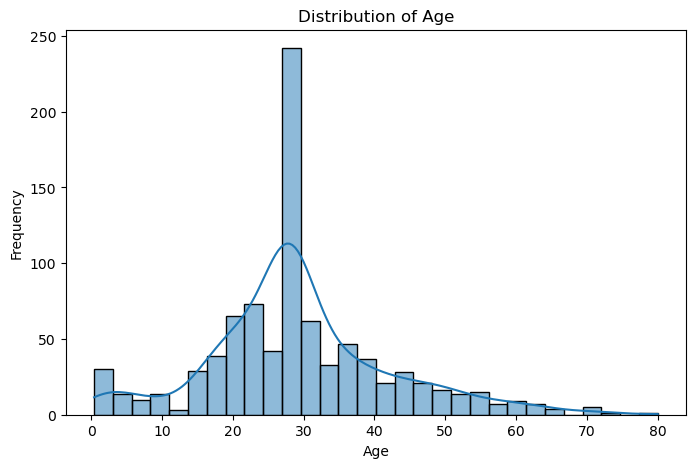

In [8]:
# Histogram of Age

plt.figure(figsize=(8, 5))

sns.histplot(cleaned_df["age"], bins=30, kde=True)

plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

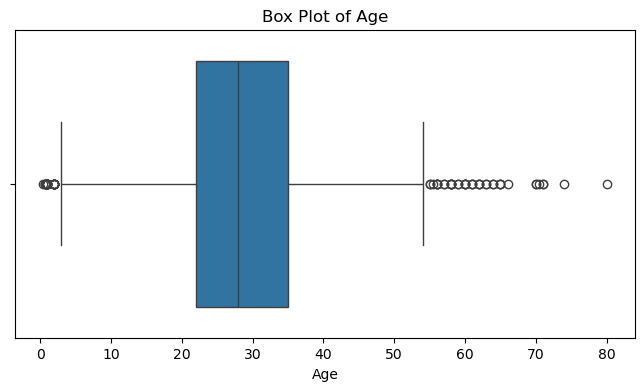

In [9]:
# Box plot of Age

plt.figure(figsize=(8, 4))

sns.boxplot(x=cleaned_df["age"])

plt.title("Box Plot of Age")
plt.xlabel("Age")

plt.show()

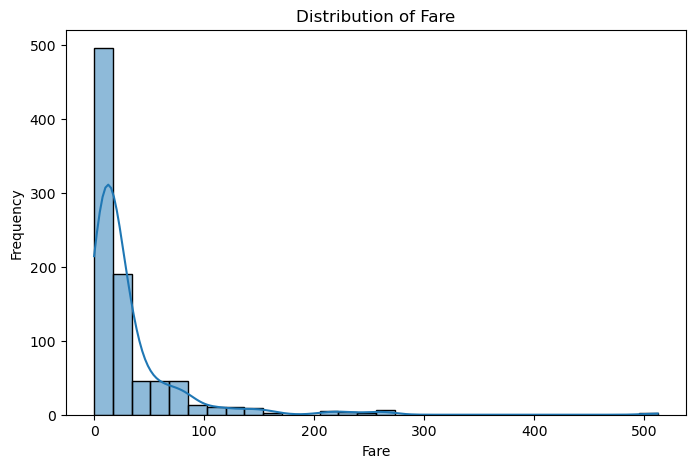

In [10]:
# Histogram of Fare

plt.figure(figsize=(8, 5))

sns.histplot(cleaned_df["fare"], bins=30, kde=True)

plt.title("Distribution of Fare")
plt.xlabel("Fare")
plt.ylabel("Frequency")

plt.show()

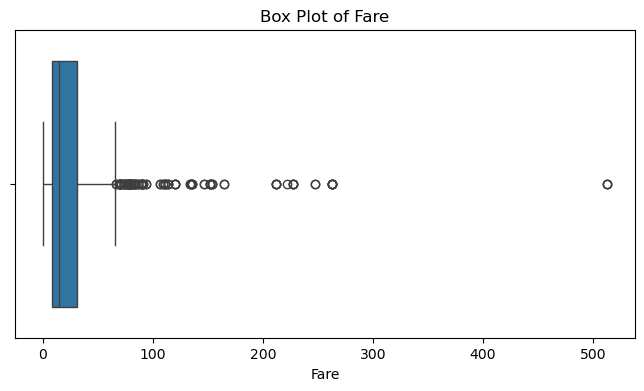

In [11]:
# Box plot of Fare

plt.figure(figsize=(8, 4))

sns.boxplot(x=cleaned_df["fare"])

plt.title("Box Plot of Fare")
plt.xlabel("Fare")

plt.show()

In [12]:
# Calculate IQR-based outliers for Age and Fare

def count_iqr_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = series[(series < lower_bound) | (series > upper_bound)]

    return Q1, Q3, IQR, lower_bound, upper_bound, len(outliers)


# Age outliers
age_q1, age_q3, age_iqr, age_lower, age_upper, age_outliers = count_iqr_outliers(
    cleaned_df["age"]
)

# Fare outliers
fare_q1, fare_q3, fare_iqr, fare_lower, fare_upper, fare_outliers = count_iqr_outliers(
    cleaned_df["fare"]
)

print("AGE")
print("Q1:", age_q1)
print("Q3:", age_q3)
print("IQR:", age_iqr)
print("Lower bound:", age_lower)
print("Upper bound:", age_upper)
print("Number of outliers:", age_outliers)

print("\nFARE")
print("Q1:", fare_q1)
print("Q3:", fare_q3)
print("IQR:", fare_iqr)
print("Lower bound:", fare_lower)
print("Upper bound:", fare_upper)
print("Number of outliers:", fare_outliers)

AGE
Q1: 22.0
Q3: 35.0
IQR: 13.0
Lower bound: 2.5
Upper bound: 54.5
Number of outliers: 65

FARE
Q1: 7.8958
Q3: 31.0
IQR: 23.1042
Lower bound: -26.7605
Upper bound: 65.6563
Number of outliers: 114


In [13]:
# Calculate mean, median and mode of Fare

fare_mean = cleaned_df["fare"].mean()
fare_median = cleaned_df["fare"].median()
fare_mode = cleaned_df["fare"].mode()[0]

print("Fare Mean:", fare_mean)
print("Fare Median:", fare_median)
print("Fare Mode:", fare_mode)

Fare Mean: 32.09668087739032
Fare Median: 14.4542
Fare Mode: 8.05


In [14]:
#Determine the skewness of Fare based on mean, median and mode
print("Fare distribution interpretation:")
if fare_mean > fare_median > fare_mode:
    print("Fare is right-skewed.")
    print("The ordering mean > median > mode indicates a longer right tail.")
elif fare_mean < fare_median < fare_mode:
    print("Fare is left-skewed.")
    print("The ordering mean < median < mode indicates a longer left tail.")
else:
    print("The mean,median and mode do not follow a simple ordering.")
    print("Inspect the histogram to determine the distribution shape.")

Fare distribution interpretation:
Fare is right-skewed.
The ordering mean > median > mode indicates a longer right tail.


Univariate Analysis Interpretation: The age plot shows how the passengers' ages are distributed, while the box plot helps identify some unusual age values. Most passengers paid lower fares, while a few passengers paid much higher fares. The fare is right-skewed because the mean (32.10) is higher than the median (14.45), and the median is higher than the mode (8.05).

In [15]:
# Survival rate by sex
survival_by_sex = cleaned_df.groupby("sex")["survived"].mean() * 100

print("Survival rate by sex:")
display(survival_by_sex)

Survival rate by sex:


sex
female    74.038462
male      18.890815
Name: survived, dtype: float64

In [16]:
# Survival rate by passenger class

survival_by_pclass = cleaned_df.groupby("pclass")["survived"].mean() * 100

print("Survival rate by passenger class:")
display(survival_by_pclass)

Survival rate by passenger class:


pclass
1    62.616822
2    47.282609
3    24.236253
Name: survived, dtype: float64

In [17]:
# Survival rate by sex and passenger class

survival_by_sex_pclass = (
    cleaned_df
    .groupby(["sex", "pclass"])["survived"]
    .mean() * 100
)

print("Survival rate by sex and passenger class:")
display(survival_by_sex_pclass)

Survival rate by sex and passenger class:


sex     pclass
female  1         96.739130
        2         92.105263
        3         50.000000
male    1         36.885246
        2         15.740741
        3         13.544669
Name: survived, dtype: float64

In [18]:
# Correlation matrix using exactly the required six columns
correlation_columns = [
    "survived",
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"
]

correlation_matrix = cleaned_df[correlation_columns].corr()

print("Correlation Matrix:")
display(correlation_matrix)

Correlation Matrix:


,survived,pclass,age,sibsp,parch,fare
survived,1.000000,-0.335549,-0.069822,-0.034040,0.083151,0.255290
pclass,-0.335549,1.000000,-0.336512,0.081656,0.016824,-0.548193
age,-0.069822,-0.336512,1.000000,-0.232543,-0.171485,0.093707
sibsp,-0.034040,0.081656,-0.232543,1.000000,0.414542,0.160887
parch,0.083151,0.016824,-0.171485,0.414542,1.000000,0.217532
fare,0.255290,-0.548193,0.093707,0.160887,0.217532,1.000000


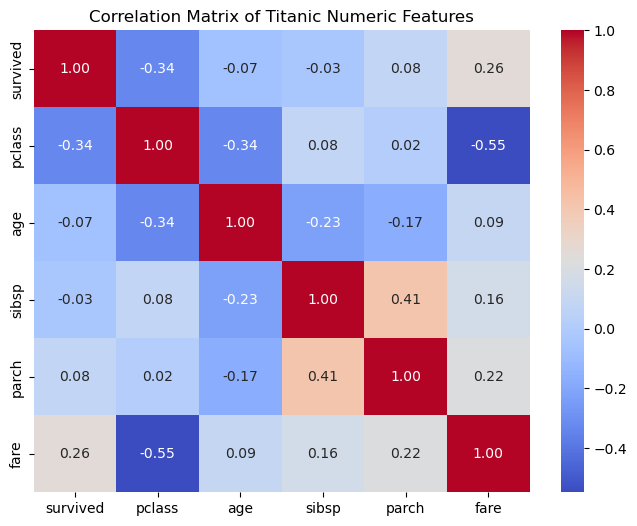

In [19]:
# Correlation heatmap

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Titanic Numeric Features")
plt.show()

In [20]:
# Find the two strongest correlations

corr_pairs = []

for i in range(len(correlation_matrix.columns)):
    for j in range(i + 1, len(correlation_matrix.columns)):
        feature_1 = correlation_matrix.columns[i]
        feature_2 = correlation_matrix.columns[j]
        correlation = correlation_matrix.iloc[i, j]

        corr_pairs.append({
            "Feature 1": feature_1,
            "Feature 2": feature_2,
            "Correlation": correlation,
            "Absolute Correlation": abs(correlation)
        })

strongest_correlations = (
    pd.DataFrame(corr_pairs)
    .sort_values("Absolute Correlation", ascending=False)
    .head(2)
)

display(strongest_correlations)

,Feature 1,Feature 2,Correlation,Absolute Correlation
8,pclass,fare,-0.548193,0.548193
12,sibsp,parch,0.414542,0.414542


In [21]:
# Survival rate by sex using boolean masking

female_survival = cleaned_df[cleaned_df["sex"] == "female"]["survived"].mean() * 100
male_survival = cleaned_df[cleaned_df["sex"] == "male"]["survived"].mean() * 100

print("Survival rate by sex:")
print(f"Female: {female_survival:.2f}%")
print(f"Male: {male_survival:.2f}%")

Survival rate by sex:
Female: 74.04%
Male: 18.89%


In [22]:
# Survival rate by passenger class using boolean masking

first_class_survival = cleaned_df[cleaned_df["pclass"] == 1]["survived"].mean() * 100
second_class_survival = cleaned_df[cleaned_df["pclass"] == 2]["survived"].mean() * 100
third_class_survival = cleaned_df[cleaned_df["pclass"] == 3]["survived"].mean() * 100

print("Survival rate by passenger class:")
print(f"1st Class: {first_class_survival:.2f}%")
print(f"2nd Class: {second_class_survival:.2f}%")
print(f"3rd Class: {third_class_survival:.2f}%")

Survival rate by passenger class:
1st Class: 62.62%
2nd Class: 47.28%
3rd Class: 24.24%


In [23]:
# Survival rate by sex and passenger class using boolean masking

female_first = cleaned_df[
    (cleaned_df["sex"] == "female") & (cleaned_df["pclass"] == 1)
]["survived"].mean() * 100

female_second = cleaned_df[
    (cleaned_df["sex"] == "female") & (cleaned_df["pclass"] == 2)
]["survived"].mean() * 100

female_third = cleaned_df[
    (cleaned_df["sex"] == "female") & (cleaned_df["pclass"] == 3)
]["survived"].mean() * 100

male_first = cleaned_df[
    (cleaned_df["sex"] == "male") & (cleaned_df["pclass"] == 1)
]["survived"].mean() * 100

male_second = cleaned_df[
    (cleaned_df["sex"] == "male") & (cleaned_df["pclass"] == 2)
]["survived"].mean() * 100

male_third = cleaned_df[
    (cleaned_df["sex"] == "male") & (cleaned_df["pclass"] == 3)
]["survived"].mean() * 100

print("Survival rate by sex and passenger class:")
print(f"Female, 1st Class: {female_first:.2f}%")
print(f"Female, 2nd Class: {female_second:.2f}%")
print(f"Female, 3rd Class: {female_third:.2f}%")
print(f"Male, 1st Class: {male_first:.2f}%")
print(f"Male, 2nd Class: {male_second:.2f}%")
print(f"Male, 3rd Class: {male_third:.2f}%")

Survival rate by sex and passenger class:
Female, 1st Class: 96.74%
Female, 2nd Class: 92.11%
Female, 3rd Class: 50.00%
Male, 1st Class: 36.89%
Male, 2nd Class: 15.74%
Male, 3rd Class: 13.54%


Bivariate Analysis Interpretation: More females survived than males. Passengers in 1st class had a higher survival rate than those in 2nd and 3rd class. Overall, females had a better chance of surviving in all three classes, while males had lower survival rates, especially in 2nd and 3rd class.

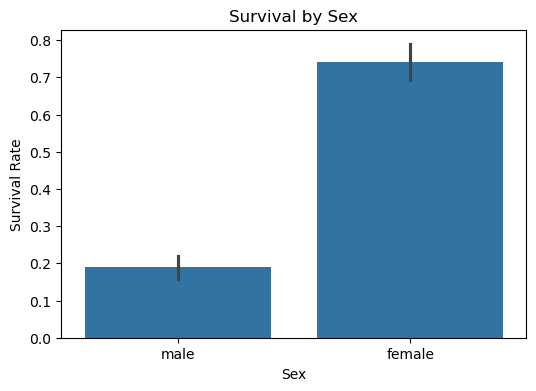

In [24]:
plt.figure(figsize=(6, 4))

sns.barplot(data=cleaned_df, x="sex", y="survived")

plt.title("Survival by Sex")
plt.xlabel("Sex")
plt.ylabel("Survival Rate")

plt.show()

Interpretation: More females survived than males. This shows that sex had a big effect on survival.

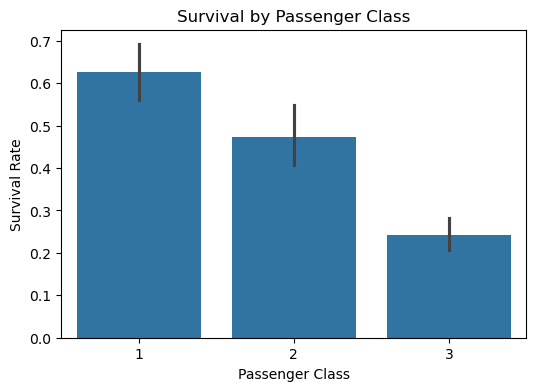

In [25]:
plt.figure(figsize=(6, 4))

sns.barplot(data=cleaned_df, x="pclass", y="survived")

plt.title("Survival by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")

plt.show()

Interpretation: First-class passengers had the highest survival rate. Third-class passengers had the lowest survival rate.

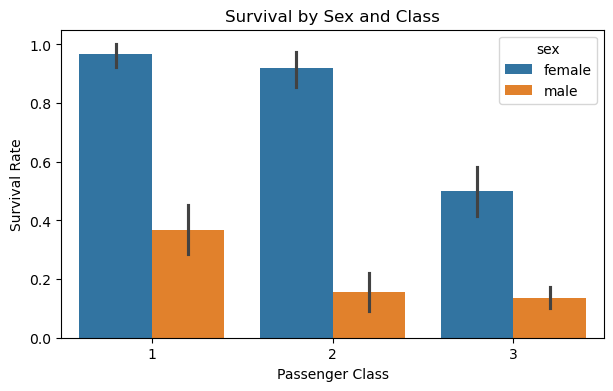

In [26]:
plt.figure(figsize=(7, 4))

sns.barplot(
    data=cleaned_df,
    x="pclass",
    y="survived",
    hue="sex"
)

plt.title("Survival by Sex and Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")

plt.show()

Interpretation: Females had a higher survival rate than males in all three classes. First-class females had the highest survival rate, while third-class males had the lowest.

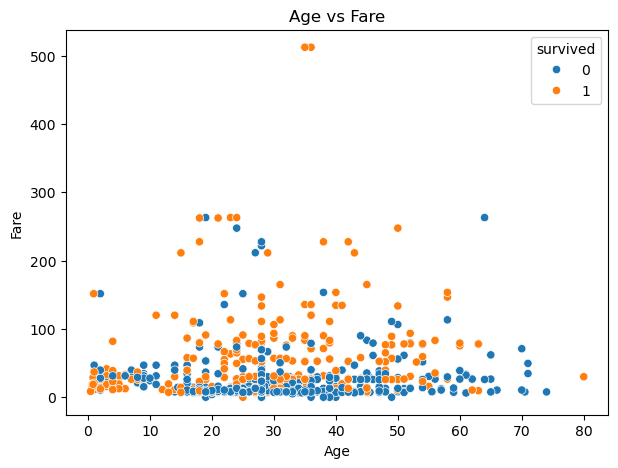

In [27]:
plt.figure(figsize=(7, 5))

sns.scatterplot(
    data=cleaned_df,
    x="age",
    y="fare",
    hue="survived"
)

plt.title("Age vs Fare")
plt.xlabel("Age")
plt.ylabel("Fare")

plt.show()

Interpretation: Most passengers paid lower fares, while a few passengers paid much higher fares. The chart also shows that fare had a stronger connection with survival than age.

In [28]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

cleaned_df[["age_scaled", "fare_scaled"]] = scaler.fit_transform(
    cleaned_df[["age", "fare"]]
)

print("Standardization completed.")

Standardization completed.


In [29]:
print("After standardization:")
print("Age mean:", cleaned_df["age_scaled"].mean())
print("Age std:", cleaned_df["age_scaled"].std())
print("Fare mean:", cleaned_df["fare_scaled"].mean())
print("Fare std:", cleaned_df["fare_scaled"].std())

After standardization:
Age mean: 2.717486278497571e-16
Age std: 1.000562904632249
Fare mean: 1.3987061727561027e-16
Fare std: 1.0005629046322495


In [30]:
comparison = pd.DataFrame({
    "Column": ["age", "fare"],
    "Before Mean": [
        cleaned_df["age"].mean(),
        cleaned_df["fare"].mean()
    ],
    "After Mean": [
        cleaned_df["age_scaled"].mean(),
        cleaned_df["fare_scaled"].mean()
    ],
    "Before Std": [
        cleaned_df["age"].std(),
        cleaned_df["fare"].std()
    ],
    "After Std": [
        cleaned_df["age_scaled"].std(),
        cleaned_df["fare_scaled"].std()
    ]
})

display(comparison)

,Column,Before Mean,After Mean,Before Std,After Std
0,age,29.315152,2.717486e-16,12.984932,1.000563
1,fare,32.096681,1.398706e-16,49.697504,1.000563
